<a href="https://colab.research.google.com/github/RobbieKing69/Mi-proyecto-devops/blob/main/Avance_proyecto_cuantica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit
!pip install matplotlib

Diagrama del circuito Grover

Generando esquema del circuito...


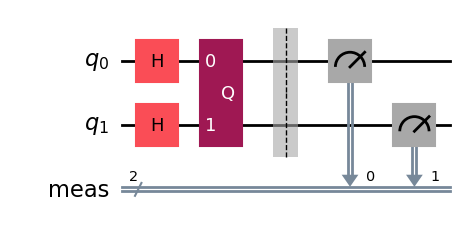

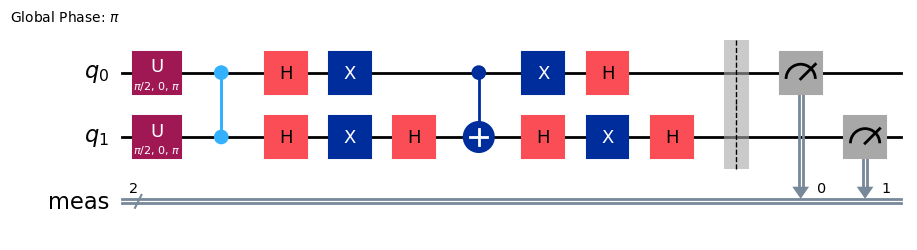


         RESULTADOS EXPERIMENTALES           
Estado Objetivo Marcado : |11>
Distribución de Conteos : {'11': 1024}
Probabilidad de Éxito   : 100.00%
✓ CRITERIO DE ÉXITO CUMPLE: Convergencia ideal comprobada.



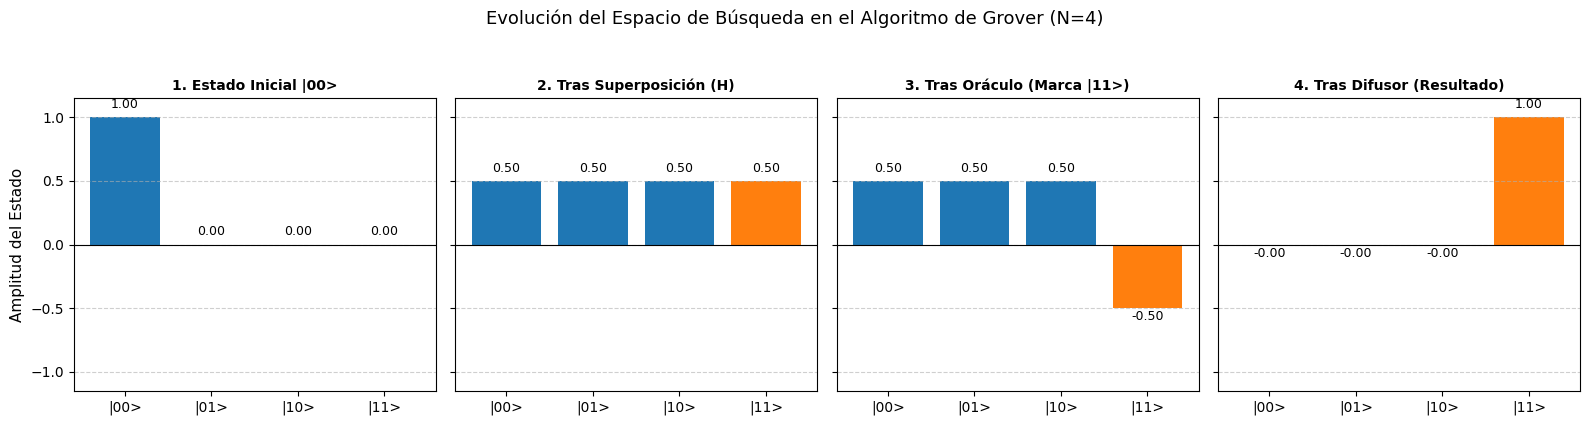

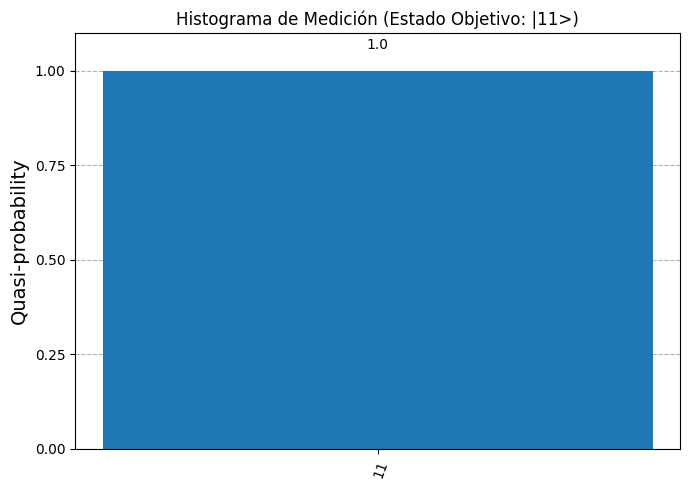

In [ ]:
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate, grover_operator
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_distribution
from IPython.display import display
from qiskit.quantum_info import Statevector

# --- 1. Definición del Oráculo Personalizado ---
def grover_oracle(marked_states):
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        rev_target = target[::-1]
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]

        if zero_inds:
            qc.x(zero_inds)

        if num_qubits == 1:
            qc.z(0)
        elif num_qubits == 2:
            qc.cz(0, 1)
        else:
            qc.compose(
                MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True
            )

        if zero_inds:
            qc.x(zero_inds)

    return qc


# --- 2. Parámetros del Proyecto (n = 2 qubits, 1 marcado) ---
TARGET_STATE = "11"
marked_states = [TARGET_STATE]
oracle = grover_oracle(marked_states)
grover_op = grover_operator(oracle)
optimal_iterations = 1

# --- 3. Construcción del Circuito Principal ---
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(grover_op.num_qubits))
qc.compose(grover_op.power(optimal_iterations), inplace=True)
qc.measure_all()

# Visualización 1: Diagrama del circuito lógico
print("Generando esquema del circuito...")
fig_circ = qc.draw('mpl')
display(fig_circ)
plt.close()

qc_desglosado = qc.decompose()
fig = qc_desglosado.draw('mpl')
display(fig)
plt.close()

# --- 4. Ejecución Experimental y Recolección de Métricas ---
SHOTS_CONFIG = 1024
sampler = StatevectorSampler()
job = sampler.run([qc], shots=SHOTS_CONFIG)
result = job.result()
counts = result[0].data.meas.get_counts()

# Cálculo de Métrica de Éxito
total_shots = sum(counts.values())
shots_correctos = counts.get(TARGET_STATE, 0)
prob_exito = (shots_correctos / total_shots) * 100

# Impresión en consola
print("\n" + "=" * 45)
print("         RESULTADOS EXPERIMENTALES           ")
print("=" * 45)
print(f"Estado Objetivo Marcado : |{TARGET_STATE}>")
print(f"Distribución de Conteos : {counts}")
print(f"Probabilidad de Éxito   : {prob_exito:.2f}%")

if prob_exito >= 98.0:
  print("✓ CRITERIO DE ÉXITO CUMPLE: Convergencia ideal comprobada.")
else:
  print("✗ ALERTA: Desviación detectada en la ejecución lógica.")
print("=" * 45 + "\n")

# --- 5. Generación de la Gráfica de Evolución de Probabilidades ---
# Construcción de circuitos intermedios para capturar el estado paso a paso
qc_s1 = QuantumCircuit(2)  # Paso 1: Estado inicial |00>
qc_s2 = QuantumCircuit(2)
qc_s2.h([0, 1])  # Paso 2: Tras Superposición (H)
qc_s3 = qc_s2.copy()
qc_s3.cz(0, 1)  # Paso 3: Tras Oráculo (Inversión de Fase)
qc_s4 = qc.remove_final_measurements(
    inplace=False
)  # Paso 4: Tras Difusor (Final)

pasos = [
    ("1. Estado Inicial |00>", Statevector.from_instruction(qc_s1)),
    ("2. Tras Superposición (H)", Statevector.from_instruction(qc_s2)),
    ("3. Tras Oráculo (Marca |11>)", Statevector.from_instruction(qc_s3)),
    ("4. Tras Difusor (Resultado)", Statevector.from_instruction(qc_s4)),
]

estados = ["|00>", "|01>", "|10>", "|11>"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i, (titulo, sv) in enumerate(pasos):
    amplitudes = sv.data.real  # Obtiene los coeficientes complejos (parte real)
    bars = axes[i].bar(
        estados,
        amplitudes,
        color=["#1f77b4" if e != f"|{TARGET_STATE}>" else "#ff7f0e" for e in estados],
    )
    axes[i].set_title(titulo, fontsize=10, fontweight="bold")
    axes[i].set_ylim(-1.15, 1.15)  # Ajustar límites para amplitudes negativas
    axes[i].axhline(0, color="black", linewidth=0.8)  # Línea cero de referencia
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        offset = 0.05 if yval >= 0 else -0.12
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            yval + offset,
            f"{yval:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

axes[0].set_ylabel("Amplitud del Estado", fontsize=11)
plt.suptitle(
    "Evolución del Espacio de Búsqueda en el Algoritmo de Grover (N=4)",
    fontsize=13,
    y=1.05,
)
plt.tight_layout()

# Mostrar la gráfica en Colab
display(fig)
plt.close()

# Visualización 2: Histograma de Probabilidades
fig_hist = plot_distribution(counts, title=f"Histograma de Medición (Estado Objetivo: |{TARGET_STATE}>)")
display(fig_hist)